In [18]:
!pip install -q opencv-python face_recognition numpy pandas ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.0 MB/s eta 0:00:00


In [19]:
import cv2, os, re, shutil, time
import numpy as np, pandas as pd
import face_recognition
import matplotlib.pyplot as plt
from datetime import datetime
from google.colab import drive, files, output
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from base64 import b64decode

In [20]:
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/face_recog/'
DATASET_DIR = os.path.join(BASE_PATH, 'dataset')
ATTENDANCE_DIR = os.path.join(BASE_PATH, 'attendance')
OUTPUT_DIR = os.path.join(BASE_PATH, 'output')
for d in [DATASET_DIR, ATTENDANCE_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
print("Ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready.


In [21]:
def upload_known_faces():
    print("Select images. Filenames will define person names.")
    uploaded = files.upload()
    for name in uploaded.keys():
        if name.lower().endswith(('.jpg', '.jpeg', '.png')):
            shutil.move(name, os.path.join(DATASET_DIR, name))
    print(f"Uploaded {len(os.listdir(DATASET_DIR))} images.")
upload_known_faces()

Select images. Filenames will define person names.


Saving boy_1.jpeg to boy_1.jpeg
Uploaded 18 images.


In [22]:
def load_known_faces(dataset_dir):
    encodings, names = [], []
    for f in os.listdir(dataset_dir):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            base = os.path.splitext(f)[0]
            name = re.sub(r'[_\d]+$', '', base) or base
            img = face_recognition.load_image_file(os.path.join(dataset_dir, f))
            face_enc = face_recognition.face_encodings(img)
            if face_enc:
                encodings.append(face_enc[0])
                names.append(name)
    return encodings, names
known_encodings, known_names = load_known_faces(DATASET_DIR)
print(f"Loaded {len(set(known_names))} unique persons.")

Loaded 9 unique persons.


In [23]:
def mark_attendance(name, attendance_dir):
    today = datetime.now().strftime("%Y-%m-%d")
    time_now = datetime.now().strftime("%H:%M:%S")
    fp = os.path.join(attendance_dir, f"attendance_{today}.csv")
    df = pd.read_csv(fp) if os.path.exists(fp) else pd.DataFrame(columns=["Name", "Time"])
    if name not in df["Name"].values:
        df = pd.concat([df, pd.DataFrame({"Name": [name], "Time": [time_now]})], ignore_index=True)
        df.to_csv(fp, index=False)

Upload test image:


Saving hell.png to hell (2).png


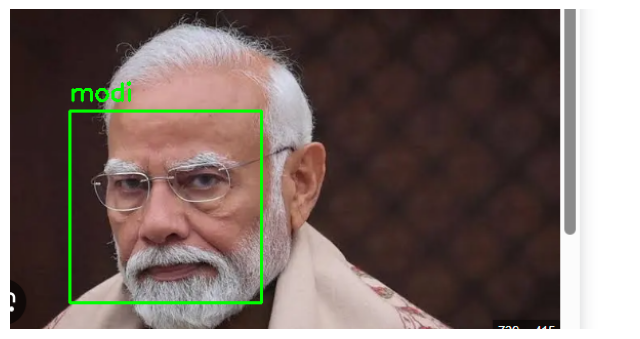

In [24]:
def recognize_image(path, enc, names, tol=0.6):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    boxes = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))
    fr_locs = [(y, x+w, y+h, x) for x, y, w, h in boxes]
    if not fr_locs: return img
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    face_encs = face_recognition.face_encodings(rgb, fr_locs)
    for (t, r, b, l), f_enc in zip(fr_locs, face_encs):
        matches = face_recognition.compare_faces(enc, f_enc, tol) if enc else []
        name = "Unknown"
        if True in matches:
            name = names[matches.index(True)]
            mark_attendance(name, ATTENDANCE_DIR)
        cv2.rectangle(img, (l, t), (r, b), (0, 255, 0), 2)
        cv2.putText(img, name, (l, t-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    return img

print("Upload test image:")
uploaded = files.upload()
for filename in uploaded.keys():
    recognize_image(filename, known_encodings, known_names)

In [30]:
def process_video(path, enc, names, out_path=None, tol=0.6):
    if out_path is None:
        out_path = os.path.join(OUTPUT_DIR, f"output_{datetime.now().strftime('%H%M%S')}.mp4")

    cap = cv2.VideoCapture(path)
    w, h = int(cap.get(3)), int(cap.get(4))
    fps = cap.get(5)
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

    # Store last known faces
    last_faces = []
    face_timeout = 0

    print("Processing...")
    fc = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        fc += 1
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect every frame
        boxes = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))
        fr_locs = [(y, x+w, y+h, x) for x, y, w, h in boxes]

        current_faces = []

        if fr_locs and enc:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            f_encs = face_recognition.face_encodings(rgb, fr_locs)

            for (t, r, b, l), f_enc in zip(fr_locs, f_encs):
                matches = face_recognition.compare_faces(enc, f_enc, tol)
                name = "Unknown"

                if True in matches:
                    name = names[matches.index(True)]
                    mark_attendance(name, ATTENDANCE_DIR)

                current_faces.append({'loc': (t, r, b, l), 'name': name})
                cv2.rectangle(frame, (l, t), (r, b), (0, 255, 0), 2)
                cv2.putText(frame, name, (l, t-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            last_faces = current_faces
            face_timeout = 0
        else:
            # Use last known faces if detection fails
            face_timeout += 1
            if face_timeout < 10 and last_faces:  # Keep for 10 frames
                for face in last_faces:
                    t, r, b, l = face['loc']
                    name = face['name']
                    cv2.rectangle(frame, (l, t), (r, b), (0, 255, 0), 2)
                    cv2.putText(frame, name, (l, t-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        out.write(frame)

        if fc % 30 == 0:
            print(f"Processed {fc} frames...")

    cap.release()
    out.release()
    print(f"Saved to {out_path}")
    print(f"Total frames: {fc}")

#UPLOAD VIDEO TEST

print("Upload video file:")
uploaded_vid = files.upload()
for filename in uploaded_vid.keys():
    if filename.endswith(('.mp4', '.avi', '.mov')):
        process_video(filename, known_encodings, known_names)

Upload video file:


Saving hell.mp4 to hell (1).mp4
Processing...
Processed 30 frames...
Processed 60 frames...
Processed 90 frames...
Processed 120 frames...
Processed 150 frames...
Processed 180 frames...
Processed 210 frames...
Processed 240 frames...
Processed 270 frames...
Processed 300 frames...
Processed 330 frames...
Processed 360 frames...
Processed 390 frames...
Processed 420 frames...
Processed 450 frames...
Processed 480 frames...
Processed 510 frames...
Processed 540 frames...
Processed 570 frames...
Processed 600 frames...
Processed 630 frames...
Processed 660 frames...
Processed 690 frames...
Processed 720 frames...
Processed 750 frames...
Processed 780 frames...
Processed 810 frames...
Processed 840 frames...
Processed 870 frames...
Saved to /content/drive/MyDrive/face_recog/output/output_170820.mp4
Total frames: 870


In [ ]:
#LIVE CAPTURE

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import time

print("Allow camera access when prompted. Click 'Quit Camera' to stop.")
print("If camera doesn't start, re-run this cell.")

quit_btn = widgets.Button(description="Quit Camera", button_style='danger')
output_area = widgets.Output()
running = {'value': True}

def on_quit(b):
    running['value'] = False
    print("Stopping camera...")

quit_btn.on_click(on_quit)
display(quit_btn)
display(output_area)

js = """
<div id="container" style="position: relative;">
    <video id="cam" autoplay playsinline style="width: 640px; height: 480px; display: none;"></video>
    <canvas id="cvs" style="width: 640px; height: 480px;"></canvas>
</div>
<script>
(function() {
    const v = document.getElementById('cam');
    const c = document.getElementById('cvs');
    const ctx = c.getContext('2d');
    c.width = 640;
    c.height = 480;
    let stream = null;

    async function init() {
        try {
            stream = await navigator.mediaDevices.getUserMedia({
                video: {width: {ideal: 640}, height: {ideal: 480}},
                facingMode: "user"
            });
            v.srcObject = stream;
            await new Promise((resolve) => { v.onloadedmetadata = resolve; });
            v.play();
            console.log("Camera initialized");
        } catch (err) {
            console.error("Camera error:", err);
            alert("Camera access denied or not available: " + err.message);
        }
    }

    window.getFrameData = function() {
        if (!v || v.readyState !== 4) return null;
        ctx.drawImage(v, 0, 0, 640, 480);
        return c.toDataURL('image/jpeg', 0.8).split(',')[1];
    };

    window.stopCameraStream = function() {
        if (stream) {
            stream.getTracks().forEach(track => track.stop());
            console.log("Camera stopped");
        }
    };

    init();
})();
</script>
"""

display(HTML(js))
time.sleep(3)

frame_count = 0
with output_area:
    while running['value']:
        try:
            b64 = output.eval_js('getFrameData()')
            if b64 is None:
                time.sleep(0.1)
                continue

            nparr = np.frombuffer(b64decode(b64), np.uint8)
            frame = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

            if frame is None or frame.size == 0:
                continue

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            boxes = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))
            fr_locs = [(y, x+w, y+h, x) for x, y, w, h in boxes]

            if fr_locs and known_encodings:
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                f_encs = face_recognition.face_encodings(rgb, fr_locs)
                for (t, r, b, l), f_enc in zip(fr_locs, f_encs):
                    matches = face_recognition.compare_faces(known_encodings, f_enc, 0.6)
                    name = "Unknown"
                    if True in matches:
                        name = known_names[matches.index(True)]
                        mark_attendance(name, ATTENDANCE_DIR)
                    cv2.rectangle(frame, (l, t), (r, b), (0, 255, 0), 2)
                    cv2.putText(frame, name, (l, t-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            frame_count += 1
            if frame_count % 5 == 0:
                clear_output(wait=True)
                display(quit_btn)
                plt.figure(figsize=(8, 6))
                plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                plt.show()

            time.sleep(0.05)

        except Exception as e:
            if not running['value']:
                break
            print(f"Frame error: {e}")
            time.sleep(0.1)

try:
    output.eval_js('stopCameraStream()')
except:
    pass

clear_output()
print(f"Camera stopped. Processed {frame_count} frames.")

In [28]:
def show_attendance():
    today = datetime.now().strftime("%Y-%m-%d")
    fp = os.path.join(ATTENDANCE_DIR, f"attendance_{today}.csv")
    if os.path.exists(fp):
        df = pd.read_csv(fp)
        print(f"Attendance for {today}:")
        display(df)
        files.download(fp)
    else:
        print(f"No attendance logged for {today}")
show_attendance()

Attendance for 2026-04-29:


,Name,Time
0,modi,16:43:14
1,vir,16:58:00
2,say,16:58:39
3,per,16:58:52
4,ran,16:58:58
5,boy,17:01:58


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
known_encodings, known_names = load_known_faces(DATASET_DIR)
print(f"Reloaded {len(set(known_names))} persons.")

Reloaded 9 persons.
